# Handwritten Digit Recognition – MNIST
This notebook compares multiple ML models with different hyperparameters.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


## Load MNIST Dataset

In [6]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X / 255.0
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Reduce dataset size for faster execution
X_train = X_train[:10000]
y_train = y_train[:10000]
X_test = X_test[:2000]
y_test = y_test[:2000]



## K-Nearest Neighbors

In [7]:
for k in [3,5,7]:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    print(f'KNN k={k} Accuracy:', accuracy_score(y_test, preds))
    print(confusion_matrix(y_test, preds))


KNN k=3 Accuracy: 0.9485
[[187   0   0   0   0   0   2   0   0   0]
 [  0 214   1   1   0   0   0   0   0   0]
 [  2   3 174   1   1   3   1   3   2   0]
 [  0   3   2 215   0   3   0   2   3   2]
 [  0   1   0   0 146   0   1   1   0   9]
 [  0   0   0   5   0 192   1   0   1   1]
 [  2   1   0   0   0   1 201   0   0   0]
 [  1   6   1   0   0   0   0 193   0   3]
 [  4   4   1   2   1   3   1   2 180   2]
 [  0   1   0   2   1   0   1   6   2 195]]
KNN k=5 Accuracy: 0.9405
[[186   0   0   0   0   0   3   0   0   0]
 [  0 214   1   1   0   0   0   0   0   0]
 [  2   5 172   1   2   2   1   4   1   0]
 [  0   3   2 214   0   3   0   4   3   1]
 [  0   1   0   0 143   0   1   1   0  12]
 [  0   0   0   7   0 190   1   0   1   1]
 [  2   1   0   0   0   2 200   0   0   0]
 [  1   6   1   0   0   0   0 192   0   4]
 [  4   5   1   4   2   5   1   1 176   1]
 [  0   2   0   2   2   0   1   5   2 194]]
KNN k=7 Accuracy: 0.9395
[[186   0   0   0   0   0   3   0   0   0]
 [  0 214   1   1   

In [8]:
# @title


## Support Vector Machine

In [9]:
for c in [1,10]:
    svm = SVC(kernel='rbf', C=c)
    svm.fit(X_train, y_train)
    preds = svm.predict(X_test)
    print(f'SVM C={c} Accuracy:', accuracy_score(y_test, preds))
    print(confusion_matrix(y_test, preds))


SVM C=1 Accuracy: 0.9615
[[188   0   0   0   0   0   1   0   0   0]
 [  0 212   2   2   0   0   0   0   0   0]
 [  0   0 186   1   1   0   1   0   1   0]
 [  0   2   5 214   0   2   0   2   4   1]
 [  2   0   0   0 153   0   0   1   0   2]
 [  1   0   0   4   0 192   2   0   1   0]
 [  1   0   0   0   1   3 200   0   0   0]
 [  0   1   1   0   2   0   0 198   0   2]
 [  0   0   1   3   3   2   4   0 186   1]
 [  0   2   0   4   1   0   0   6   1 194]]
SVM C=10 Accuracy: 0.9695
[[188   0   0   0   0   0   1   0   0   0]
 [  0 213   2   1   0   0   0   0   0   0]
 [  0   0 185   2   1   0   1   0   1   0]
 [  1   1   4 220   0   1   0   1   1   1]
 [  2   0   1   0 154   0   0   1   0   0]
 [  0   0   0   4   0 195   0   0   1   0]
 [  1   0   0   0   0   2 202   0   0   0]
 [  0   0   2   0   2   0   0 197   0   3]
 [  2   0   1   3   2   2   4   0 185   1]
 [  0   0   0   2   1   0   0   4   1 200]]


## Logistic Regression

In [10]:
for c in [1.0, 0.1]:
    lr = LogisticRegression(C=c, max_iter=200)
    lr.fit(X_train, y_train)
    preds = lr.predict(X_test)
    print(f'LogReg C={c} Accuracy:', accuracy_score(y_test, preds))
    print(confusion_matrix(y_test, preds))


LogReg C=1.0 Accuracy: 0.9085
[[182   0   0   0   0   3   3   0   1   0]
 [  0 209   1   2   0   3   0   0   1   0]
 [  1   1 170   5   3   0   5   2   3   0]
 [  0   3   9 199   0   7   0   5   5   2]
 [  0   0   3   1 141   1   1   2   2   7]
 [  0   0   2   7   2 180   1   0   6   2]
 [  3   1   3   0   1   4 192   1   0   0]
 [  1   0   6   0   2   1   0 188   0   6]
 [  5   3   2   7   2   5   3   1 170   2]
 [  0   1   1   4   3   0   0   8   5 186]]
LogReg C=0.1 Accuracy: 0.909
[[184   0   0   0   0   2   3   0   0   0]
 [  0 208   1   3   0   3   0   0   1   0]
 [  1   1 169   6   3   0   3   4   3   0]
 [  0   2   9 200   0   7   1   5   4   2]
 [  1   0   3   0 144   0   1   1   2   6]
 [  0   1   2   7   3 179   1   0   6   1]
 [  1   1   3   0   2   4 194   0   0   0]
 [  1   1   6   0   2   1   0 188   0   5]
 [  4   4   3   8   2   6   1   0 169   3]
 [  0   3   0   5   5   0   0   8   4 183]]


## Decision Tree

In [11]:
for depth in [10,20]:
    dt = DecisionTreeClassifier(max_depth=depth)
    dt.fit(X_train, y_train)
    preds = dt.predict(X_test)
    print(f'DT depth={depth} Accuracy:', accuracy_score(y_test, preds))
    print(confusion_matrix(y_test, preds))



DT depth=10 Accuracy: 0.832
[[173   0   0   1   3   4   5   1   1   1]
 [  0 199   3   5   0   1   1   6   0   1]
 [  1   2 158   6   3   1   7   3   7   2]
 [  1   1   6 192   0  10   3   6   8   3]
 [  5   0   0   2 128   4   4   5   2   8]
 [  3   2   4  13   3 153   2   6   7   7]
 [  8   2   6   4   5   5 167   2   4   2]
 [  2   0   3   1   5   0   0 186   2   5]
 [  1   7   7   3   4   6   8   9 146   9]
 [  2   2   1   7   2  11   2  11   8 162]]
DT depth=20 Accuracy: 0.8185
[[169   0   2   3   3   2   7   2   0   1]
 [  0 198   3   4   0   1   1   6   1   2]
 [  1   3 152   8   4   4   5   4   8   1]
 [  1   3   7 186   1   9   4   4   9   6]
 [  3   0   2   4 125   1   5   4   3  11]
 [  7   1   0  16   6 148   5   3   7   7]
 [  4   2   3   4   6   6 169   2   7   2]
 [  3   0   2   3   3   0   0 183   2   8]
 [  0   8   5   8   3  10   8   6 147   5]
 [  1   1   3   7   6  10   0  11   9 160]]


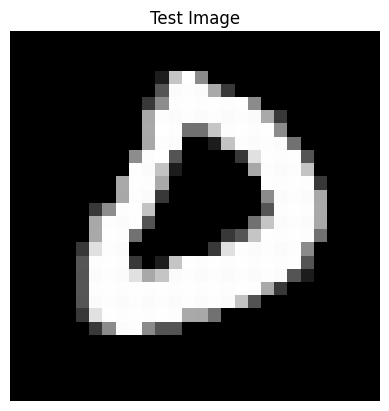

Predicted Digit: 0
Actual Digit: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [12]:
# Show a test image and predict its digit

index = 5   # change this number to see different images

sample_image = X_test.iloc[index].values.reshape(28, 28)

plt.imshow(sample_image, cmap='gray')
plt.axis('off')
plt.title("Test Image")
plt.show()

# Use the best model (SVM here)
svm = SVC(kernel='rbf', C=10)
svm.fit(X_train, y_train)

prediction = svm.predict(X_test.iloc[index].values.reshape(1, -1))
print("Predicted Digit:", prediction[0])
print("Actual Digit:", y_test.iloc[index])
